#**Лабораторная работа №2: «Разработка сверточной нейронной сети с использованием PyTorch»**

In [ ]:
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Определение преобразований
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Загрузка датасета для демонастрации
dataset = torchvision.datasets.CIFAR10(
    root='./data/show',
    train=True,
    download=True,
    transform=transform
)


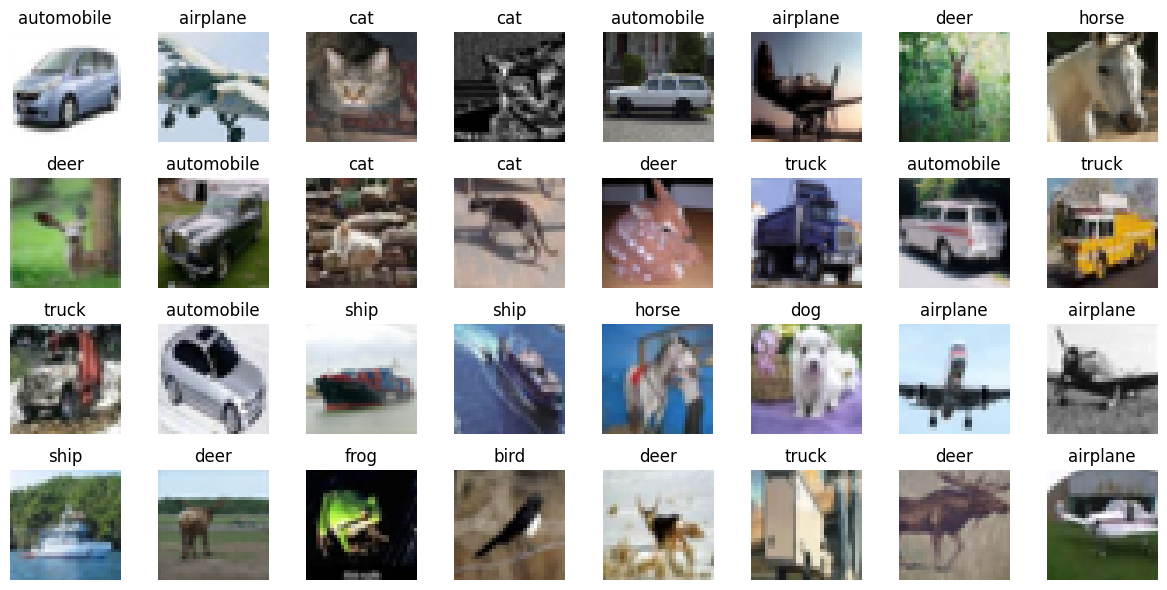

In [ ]:
import torch
loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)
# Названия классов
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# Получение одного батча данных
dataiter = iter(loader)
images, labels = next(dataiter)

# Вывод изображений
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        # Конвертация из тензора в numpy для отображения
        img = images[i].numpy().transpose((1, 2, 0))
        ax.imshow(img)
        ax.set_title(classes[labels[i]])
        ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, StepLR, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# ==================== 1. Устройство ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# ==================== 2. Данные ====================
def get_dataloaders(batch_size=128):
    """Создание DataLoader с аугментацией"""

    # Аугментация для обучения
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomCrop(32, padding=4),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                           (0.2470, 0.2435, 0.2616))
    ])

    # Только нормализация для теста
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                           (0.2470, 0.2435, 0.2616))
    ])

    # Загрузка датасетов
    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train)

    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test)

    # Вывод информации
    print(f"Размер обучающего датасета: {len(trainset)}")
    print(f"Размер тестового датасета: {len(testset)}")
    print()

    # Создание DataLoader
    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True)

    testloader = torch.utils.data.DataLoader(
        testset, batch_size=100, shuffle=False,
        num_workers=2, pin_memory=True)

    return trainloader, testloader


Используемое устройство: cuda


##**Residual Block**
Решает проблему затухающих градиентов

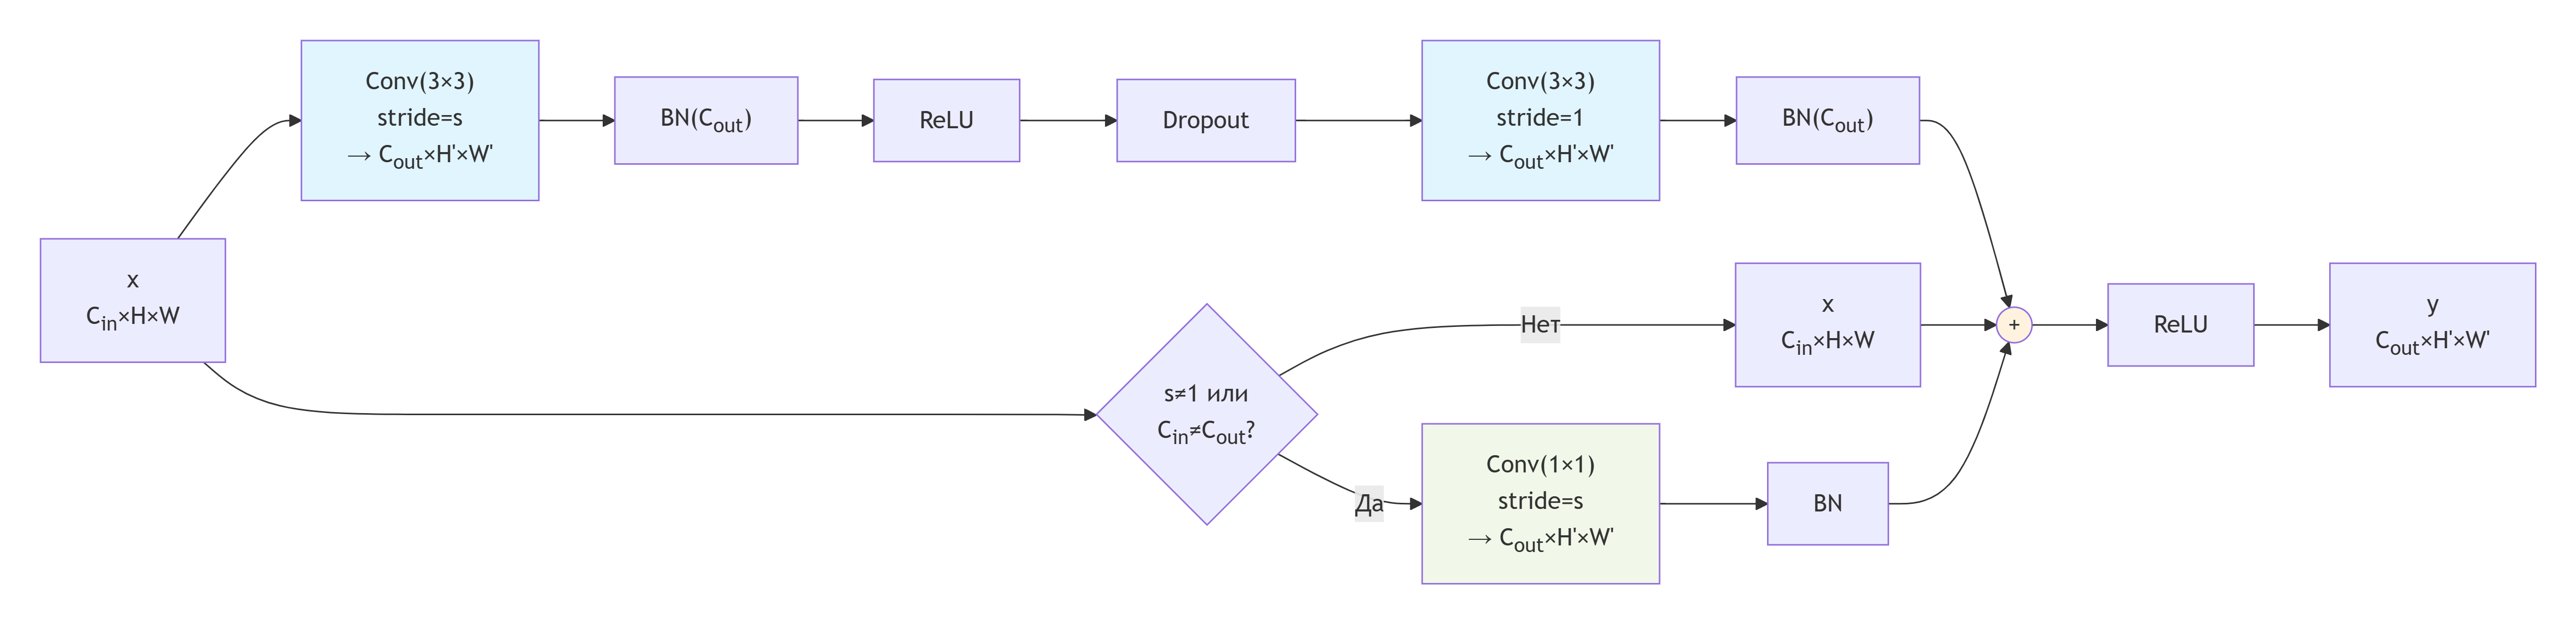

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.0):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Dropout (опционально)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

        # Shortcut connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                         kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(residual)
        out = self.relu(out)
        return out

Архитектура всей нейронной сети:


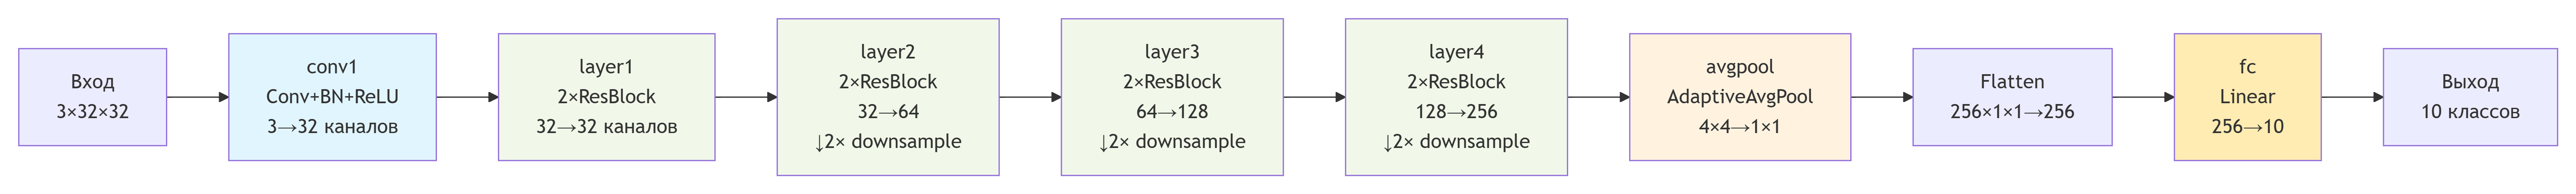

In [ ]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.0):
        super(ImprovedCNN, self).__init__()

        # Начальный слой
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        # Residual блоки с увеличенной глубиной
        self.layer1 = self._make_layer(32, 32, 2, stride=1, dropout=dropout)
        self.layer2 = self._make_layer(32, 64, 2, stride=2, dropout=dropout)
        self.layer3 = self._make_layer(64, 128, 2, stride=2, dropout=dropout)

        # Дополнительный слой для CIFAR-10
        self.layer4 = self._make_layer(128, 256, 2, stride=2, dropout=dropout)

        # Глобальный average pooling
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Классификатор
        self.fc = nn.Linear(256, num_classes)

        # Инициализация весов
        self._initialize_weights()

    def _make_layer(self, in_channels, out_channels, blocks, stride, dropout=0.0):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride, dropout))
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels, stride=1, dropout=dropout))
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [ ]:
def train_epoch(model, loader, criterion, optimizer, epoch):
    """Одна эпоха обучения"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f'Epoch {epoch+1} [Train]')
    for inputs, targets in pbar:
        inputs, targets = inputs.to(device), targets.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Статистика
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        # Обновление progress bar
        pbar.set_postfix({
            'Loss': running_loss/len(loader),
            'Acc': 100.*correct/total
        })

    return running_loss/len(loader), 100.*correct/total

def test_epoch(model, testloader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    test_loss = running_loss/len(testloader)
    test_acc = 100.*correct/total

    return test_loss, test_acc

In [ ]:
from google.colab import drive

# 1. Монтируем Google Drive
drive.mount('/content/drive')

# 2. Теперь можно сохранять прямо в Drive
model_save_path = '/content/drive/MyDrive/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Добавляем в основной цикл
best_acc = 0
patience = 20  # сколько эпох ждать улучшения
no_improve = 0
best_epoch = 0

# Функция для проверки улучшения
def is_better(current_acc, best_acc, min_delta=0.001):
    """Улучшилось ли качество хотя бы на min_delta?"""
    return current_acc > best_acc + min_delta

Размер обучающего датасета: 50000
Размер тестового датасета: 10000

Всего параметров: 2,797,610
Обучаемых параметров: 2,797,610
Начинаем обучение...


Epoch 1 [Train]: 100%|██████████| 391/391 [00:39<00:00,  9.78it/s, Loss=1.85, Acc=32.2]


  → Новый рекорд: 46.34% (сохранено)
Epoch 1/60:
  Train Loss: 1.8535, Train Acc: 32.17%
  Test Loss: 1.4557, Test Acc: 46.34%
  Best Acc: 46.34% (epoch 1)
  No improve: 0/20
--------------------------------------------------


Epoch 2 [Train]: 100%|██████████| 391/391 [00:39<00:00,  9.80it/s, Loss=1.29, Acc=53.3]


  → Новый рекорд: 55.20% (сохранено)
Epoch 2/60:
  Train Loss: 1.2899, Train Acc: 53.33%
  Test Loss: 1.2628, Test Acc: 55.20%
  Best Acc: 55.20% (epoch 2)
  No improve: 0/20
--------------------------------------------------


...

Epoch 58/60:
  Train Loss: 0.0172, Train Acc: 99.58%
  Test Loss: 0.2249, Test Acc: 93.58%
  Best Acc: 93.67% (epoch 57)
  No improve: 1/20
--------------------------------------------------


Epoch 59 [Train]: 100%|██████████| 391/391 [00:39<00:00, 10.01it/s, Loss=0.0173, Acc=99.6]


  → Новый рекорд: 93.71% (сохранено)
Epoch 59/60:
  Train Loss: 0.0173, Train Acc: 99.56%
  Test Loss: 0.2271, Test Acc: 93.71%
  Best Acc: 93.71% (epoch 59)
  No improve: 0/20
--------------------------------------------------


Epoch 60 [Train]: 100%|██████████| 391/391 [00:41<00:00,  9.49it/s, Loss=0.0165, Acc=99.6]


Epoch 60/60:
  Train Loss: 0.0165, Train Acc: 99.60%
  Test Loss: 0.2254, Test Acc: 93.62%
  Best Acc: 93.71% (epoch 59)
  No improve: 1/20
--------------------------------------------------


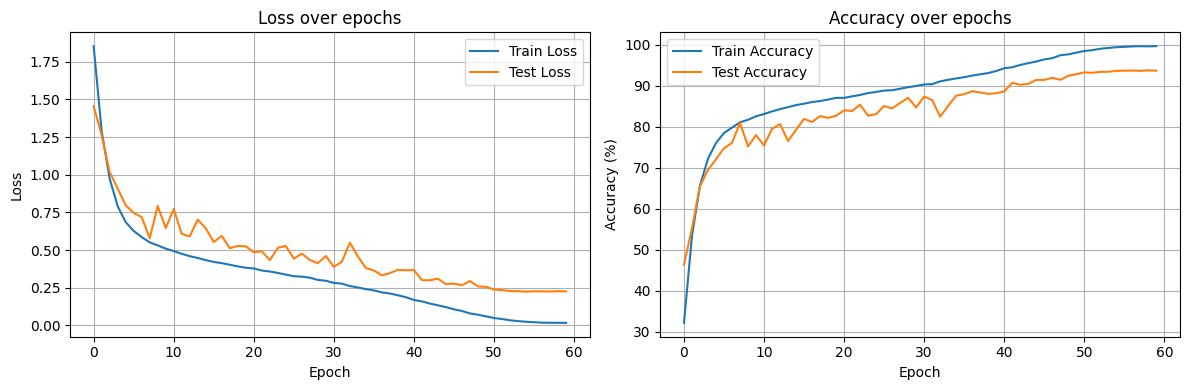

Лучшая точность на тесте: 93.71%


In [ ]:
BATCH_SIZE = 128
NUM_EPOCHS = 60  # ResNet требует больше эпох!
LR = 0.1  # Большой LR для SGD
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
DROPOUT = 0.0  # Можно поставить 0.1-0.2 для регуляризации

# Данные
trainloader, testloader = get_dataloaders(BATCH_SIZE)

# Модель
model = ImprovedCNN(num_classes=10, dropout=DROPOUT).to(device)

# Подсчет параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")

# Оптимизатор (SGD лучше для ResNet!)
optimizer = optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    nesterov=True
)


scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
criterion = nn.CrossEntropyLoss()

# 6. Основной цикл обучения

train_losses, train_accs = [], []
test_losses, test_accs = [], []

print("Начинаем обучение...")
for epoch in range(NUM_EPOCHS):
    # Обучение
    train_loss, train_acc = train_epoch(model, trainloader, criterion, optimizer, epoch)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Тестирование
    test_loss, test_acc = test_epoch(model, testloader, criterion)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    # Обновление learning rate
    scheduler.step()

    if is_better(test_acc, best_acc, min_delta=0.001):
        best_acc = test_acc
        best_epoch = epoch
        no_improve = 0

        # Сохраняем лучшую модель
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'test_acc': test_acc,
            'train_acc': train_acc,
        }, model_save_path + 'best_model.pth')

        print(f'  → Новый рекорд: {test_acc:.2f}% (сохранено)')
    else:
        no_improve += 1

    print(f'Epoch {epoch+1}/{NUM_EPOCHS}:')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')
    print(f'  Best Acc: {best_acc:.2f}% (epoch {best_epoch+1})')
    print(f'  No improve: {no_improve}/{patience}')
    print('-' * 50)

    # Ранняя остановка
    if no_improve >= patience:
        print(f'\n⚠️  Ранняя остановка на эпохе {epoch+1}')
        print(f'Лучшая точность: {best_acc:.2f}% на эпохе {best_epoch+1}')
        break

# 7. Визуализация результатов
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# График потерь
ax1.plot(train_losses, label='Train Loss')
ax1.plot(test_losses, label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss over epochs')
ax1.legend()
ax1.grid(True)

# График точности
ax2.plot(train_accs, label='Train Accuracy')
ax2.plot(test_accs, label='Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy over epochs')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# 8. Сохранение модели
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'test_accs': test_accs,
}, model_save_path + 'cifar10_cnn.pth')

print(f'Лучшая точность на тесте: {max(test_accs):.2f}%')
